<a href="https://colab.research.google.com/github/ramalakshmimscit-cloud/Main-Project-Health-Tracker-Analysis-using-Python/blob/main/HEALTH_TRACKER_ANALYSIS_FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HEALTH** **TRACKER** **ANALYSIS** **USING** **PYTHON**



# **Objective**(**Problem** **statment**)
* **Raw Data Overload**: Wearable technology generates massive amounts of health and fitness data, but companies struggle to convert this raw information into actionable business strategies.
* **Unclear Premium Subscription Drivers**: Brands lack clear insight into the specific behavioral patterns and engagement levels that motivate a user to transition from a free tier to a premium subscription.
* **Hardware Engagement Gaps**: It is unclear how different demographic groups interact with wearable hardware and which specific device features maximize daily user engagement.
* **Behavioral Analytics:** Companies often fail to map the complex relationships between a user's dietary choices, lifestyle habits, and their long-term platform retention.
* **Inability to Personalize:** Without these data-driven insights, businesses cannot effectively tailor health recommendations, optimize hardware designs, or reduce subscription churn.


# Outcome
* Constructing complete programmatic data manipulation pipelines in Python.
* Transforming unstructured textual elements (hashtags) into structured data frames.
* Handling missing values logically using statistical grouping distributions.
* Developing complex multi-variable exploratory plots to explain behavioral habits.
* Utilizing advanced Pandas indexing, merging, and grouping mechanisms on large arrays.
* Turning messy tracking metrics into intuitive, well-structured analytical observations.


# Domain
* Healthcare Informatics
* Wearable Technology Analytics
* User Behavior & Lifestyle Analytics

#**Dataset Information**

**Source:** Google datasets: https://datasetsearch.research.google.com/

**Year / Timeline:** The entries are from  April 2026 and May 2026.

**Dataset Column/features Description:**

1. **user_id**: Unique identifier for each tracked user.
1. **age**: The age of the individual user.
1. **gender**: Identified gender category.
1. **country**: Geographic location of the user.
1. **device_model**: Name of the wearable fitness tracker model.
1. **activity_type**: Main exercise logged during that session.
1. **active_minutes**: Duration of active exercise in minutes.
1. **sleep_duration_mins**: Total sleep tracked during the night cycle in minutes.
1. **sync_time**: Timestamp showing when data synced to the server.
1. **has_premium**: Boolean flag (TRUE/FALSE) for premium subscriptions.
1. **logged_food_tags**: Dietary preferences or logs tagged by the user.
1. **steps_counted**: Total physical steps recorded by the tracker.

##  Problem Definition and Dataset Selection

# **Inital EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset directly from the source URL
df = pd.read_csv("https://raw.githubusercontent.com/ramalakshmimscit-cloud/Main-Project-Health-Tracker-Analysis-using-Python/refs/heads/main/health_tracker_analytics_5000.csv")

# Display the dataframe
df


,user_id,age,gender,country,device_model,activity_type,active_minutes,sleep_duration_mins,sync_time,has_premium,logged_food_tags,steps_counted,calories_burned,avg_heart_rate,battery_drain_pct,fitness_score,app_sentiment
0,USR-93810,61,Other,Brazil,FitTrack_v4,cycling,53,378,2026-05-05 15:31:44,False,#keto,6491,495,124,28,56.0,neutral
1,USR-24592,65,Other,Australia,AeroBand_Lite,HIIT,26,412,2026-05-13 15:31:44,True,#low_carb,3184,243,149,11,40.0,negative
2,USR-13278,53,Female,Brazil,AeroBand_Lite,running,59,332,2026-05-19 15:31:44,False,#keto,7225,551,147,6,57.4,neutral
3,USR-46048,32,Female,Germany,FitTrack_v4,HIIT,17,443,2026-04-30 15:31:44,True,#none,2082,158,163,32,35.8,negative
4,USR-42098,65,Male,Australia,FitTrack_v4,walking,66,361,2026-04-25 15:31:44,True,#vegan,8083,617,109,25,63.6,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,USR-14234,43,Male,United States,FitTrack_v4,cycling,68,406,2026-05-05 15:31:44,True,#keto,8328,635,93,35,67.4,neutral
4996,USR-57013,61,Male,Brazil,FitTrack_v4,running,82,480,2026-05-17 15:31:44,False,#vegan,10042,766,168,34,80.8,positive
4997,USR-69322,62,Other,Brazil,AeroBand_Lite,cycling,16,407,2026-04-26 15:31:44,False,#high_protein,1959,149,118,8,33.2,negative
4998,USR-23432,53,Other,United Kingdom,FitTrack_v4,cycling,56,393,2026-05-13 15:31:44,True,#keto,6858,523,112,35,58.8,neutral


## Dataset Description

In [ ]:
df.shape

(5000, 17)

* Total Rows: 5,000 user entries.
* Total Columns: 17 variables tracked per user.
* Total Data Points (Size): 85,000 individual data cells (5000 rows × 17 columns).

In [ ]:
df.size

85000

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              5000 non-null   object 
 1   age                  5000 non-null   int64  
 2   gender               5000 non-null   object 
 3   country              5000 non-null   object 
 4   device_model         5000 non-null   object 
 5   activity_type        5000 non-null   object 
 6   active_minutes       5000 non-null   int64  
 7   sleep_duration_mins  5000 non-null   int64  
 8   sync_time            5000 non-null   object 
 9   has_premium          5000 non-null   bool   
 10  logged_food_tags     5000 non-null   object 
 11  steps_counted        5000 non-null   int64  
 12  calories_burned      5000 non-null   int64  
 13  avg_heart_rate       5000 non-null   int64  
 14  battery_drain_pct    5000 non-null   int64  
 15  fitness_score        5000 non-null   f

In [ ]:
df.head()

,user_id,age,gender,country,device_model,activity_type,active_minutes,sleep_duration_mins,sync_time,has_premium,logged_food_tags,steps_counted,calories_burned,avg_heart_rate,battery_drain_pct,fitness_score,app_sentiment
0,USR-93810,61,Other,Brazil,FitTrack_v4,cycling,53,378,2026-05-05 15:31:44,False,#keto,6491,495,124,28,56.0,neutral
1,USR-24592,65,Other,Australia,AeroBand_Lite,HIIT,26,412,2026-05-13 15:31:44,True,#low_carb,3184,243,149,11,40.0,negative
2,USR-13278,53,Female,Brazil,AeroBand_Lite,running,59,332,2026-05-19 15:31:44,False,#keto,7225,551,147,6,57.4,neutral
3,USR-46048,32,Female,Germany,FitTrack_v4,HIIT,17,443,2026-04-30 15:31:44,True,#none,2082,158,163,32,35.8,negative
4,USR-42098,65,Male,Australia,FitTrack_v4,walking,66,361,2026-04-25 15:31:44,True,#vegan,8083,617,109,25,63.6,neutral


In [ ]:
df.tail()

,user_id,age,gender,country,device_model,activity_type,active_minutes,sleep_duration_mins,sync_time,has_premium,logged_food_tags,steps_counted,calories_burned,avg_heart_rate,battery_drain_pct,fitness_score,app_sentiment
4995,USR-14234,43,Male,United States,FitTrack_v4,cycling,68,406,2026-05-05 15:31:44,True,#keto,8328,635,93,35,67.4,neutral
4996,USR-57013,61,Male,Brazil,FitTrack_v4,running,82,480,2026-05-17 15:31:44,False,#vegan,10042,766,168,34,80.8,positive
4997,USR-69322,62,Other,Brazil,AeroBand_Lite,cycling,16,407,2026-04-26 15:31:44,False,#high_protein,1959,149,118,8,33.2,negative
4998,USR-23432,53,Other,United Kingdom,FitTrack_v4,cycling,56,393,2026-05-13 15:31:44,True,#keto,6858,523,112,35,58.8,neutral
4999,USR-90754,37,Other,United Kingdom,AeroBand_Lite,HIIT,39,428,2026-05-23 15:31:44,False,#low_carb,4776,364,142,9,49.5,negative


In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'device_model', 'activity_type',
       'active_minutes', 'sleep_duration_mins', 'sync_time', 'has_premium',
       'logged_food_tags', 'steps_counted', 'calories_burned',
       'avg_heart_rate', 'battery_drain_pct', 'fitness_score',
       'app_sentiment'],
      dtype='object')

In [ ]:
df.select_dtypes(include='number').columns

Index(['age', 'active_minutes', 'sleep_duration_mins', 'steps_counted',
       'calories_burned', 'avg_heart_rate', 'battery_drain_pct',
       'fitness_score'],
      dtype='object')

In [ ]:
df.select_dtypes(include='object').columns

Index(['user_id', 'gender', 'country', 'device_model', 'activity_type',
       'sync_time', 'logged_food_tags', 'app_sentiment'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
device_model,0
activity_type,0
active_minutes,0
sleep_duration_mins,0
sync_time,0
has_premium,0


In [ ]:
df.describe()

,age,active_minutes,sleep_duration_mins,steps_counted,calories_burned,avg_heart_rate,battery_drain_pct,fitness_score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,41.86760,49.960400,419.255800,6118.282200,466.729200,125.49740,20.866600,56.261420
std,13.89385,23.381509,68.949346,2863.599749,218.667919,24.91159,8.908371,15.891685
min,18.00000,10.000000,300.000000,1224.000000,93.000000,90.00000,5.000000,23.400000
25%,30.00000,29.000000,360.000000,3551.000000,271.000000,105.00000,15.000000,43.000000
50%,42.00000,50.000000,419.000000,6123.000000,467.000000,120.00000,21.000000,56.400000
75%,54.00000,70.000000,478.000000,8573.000000,654.000000,148.00000,28.000000,69.200000
max,65.00000,90.000000,540.000000,11022.000000,841.000000,175.00000,35.000000,89.300000


* Age Profile: Users range from 18 to 65 years old, with an average age of roughly 42.
* Heart Rate: The average working heart rate sits at 125 bpm (ranging from a resting 90 bpm to a peak of 175 bpm).
* Overall Fitness: The calculated fitness_score spans from 23.4 to 89.3, centering around an average score of 56.2
* Physical Movement: Users average 6,118 steps and 466 calories burned per tracking session.
* Exercise Intensity: On average, users log ~50 active minutes daily, peaking at a maximum of 90 minutes.
* Sleep Routine: Average sleep duration is 419 minutes (~7 hours), with a tight distribution ranging between 5 hours (300 mins) and 9 hours (540 mins).


In [ ]:
df.duplicated().sum()

np.int64(0)

* There are zero identical rows or double-logged entries in dataset, confirming that all 5000 user logs represent unique data points.

In [ ]:
df.describe(include='object')

,user_id,gender,country,device_model,activity_type,sync_time,logged_food_tags,app_sentiment
count,5000,5000,5000,5000,5000,5000,5000,5000
unique,4852,3,7,4,6,31,6,3
top,USR-82512,Male,India,PulseMax_Pro,walking,2026-05-01 15:31:44,#balanced,neutral
freq,4,1718,741,1292,872,179,902,2320


## Data Cleaning and Pre-processing

In [ ]:
# Rename columns
rename_dict = {
    'sleep_duration_mins': 'sleep_mins',
    'active_minutes': 'active_mins',
    'battery_drain_pct': 'battery_drain',
    'avg_heart_rate': 'avg_hr'
}
df.rename(columns=rename_dict, inplace=True)

In [ ]:
df['gender'].value_counts()


,count
gender,
Male,1718
Female,1644
Other,1638


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   object 
 1   age               5000 non-null   int64  
 2   gender            5000 non-null   object 
 3   country           5000 non-null   object 
 4   device_model      5000 non-null   object 
 5   activity_type     5000 non-null   object 
 6   active_mins       5000 non-null   int64  
 7   sleep_mins        5000 non-null   int64  
 8   sync_time         5000 non-null   object 
 9   has_premium       5000 non-null   bool   
 10  logged_food_tags  5000 non-null   object 
 11  steps_counted     5000 non-null   int64  
 12  calories_burned   5000 non-null   int64  
 13  avg_hr            5000 non-null   int64  
 14  battery_drain     5000 non-null   int64  
 15  fitness_score     5000 non-null   float64
 16  app_sentiment     5000 non-null   object 


In [ ]:
#  Impute or Drop
# Numerical:median

# Categorical: Impute with mode or 'unknown'
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['logged_food_tags'] = df['logged_food_tags'].fillna('no_tags')

### **Data Cleaning: Handling Missing Values (Imputation)**

1. **Numerical Features**: Evaluated missing elements and applied a **Median Imputation**  
2. **Categorical Features**:
   * **Gender**: Missing entries were replaced using the **Mode** (most frequent value) of the population sequence via explicit zero-indexing (`.mode()[0]`).
   * **Food Tags**: Null values were systematically filled with a semantic baseline marker (`'no_tags'`) to prevent analytical loss during tokenization or food group segmentation.


In [ ]:
df.count()

,0
user_id,5000
age,5000
gender,5000
country,5000
device_model,5000
activity_type,5000
active_mins,5000
sleep_mins,5000
sync_time,5000
has_premium,5000


In [ ]:
df.logged_food_tags

,logged_food_tags
0,#keto
1,#low_carb
2,#keto
3,#none
4,#vegan
...,...
4995,#keto
4996,#vegan
4997,#high_protein
4998,#keto


In [ ]:
# Sort by user and time to ensure sequential order for analysis
df['sync_time'] = pd.to_datetime(df['sync_time'])
df = df.sort_values(by=['user_id', 'sync_time']).reset_index(drop=True)


* Sync_time column is now successfully registered as a datetime64[ns] object rather than a generic text string object.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   object        
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   device_model      5000 non-null   object        
 5   activity_type     5000 non-null   object        
 6   active_mins       5000 non-null   int64         
 7   sleep_mins        5000 non-null   int64         
 8   sync_time         5000 non-null   datetime64[ns]
 9   has_premium       5000 non-null   bool          
 10  logged_food_tags  5000 non-null   object        
 11  steps_counted     5000 non-null   int64         
 12  calories_burned   5000 non-null   int64         
 13  avg_hr            5000 non-null   int64         
 14  battery_drain     5000 n

In [ ]:
# Keep only the latest entry for each unique user_id
df_unique_users = df.drop_duplicates(subset=['user_id'], keep='last').reset_index(drop=True)

print(f"Original records: {len(df)}")
print(f"Remaining unique users: {len(df_unique_users)}")


Original records: 5000
Remaining unique users: 4852


### **Data Cleaning: Handling User Duplicates**

1. **Chronological Preservation**: Because the dataframe was previously structured sequentially by `user_id` and `sync_time`, dropping duplicates while specifying `keep='last'` guarantees that only the most recent behavioral record for each individual is retained.
2. **Data Reduction Validation**:
   * **Initial Record Base**: 5,000 logs
   * **Unique User Base Retained**: 4,852 distinct profiles
   


In [ ]:
# Identify numerical columns for distribution testing
numerical_metrics = ['steps_counted', 'calories_burned', 'battery_drain']

for col in numerical_metrics:
    skew_val = df_unique_users[col].skew()
    print(f"Column: {col:<20} | Skewness: {skew_val:.4f}")


Column: steps_counted        | Skewness: -0.0053
Column: calories_burned      | Skewness: -0.0057
Column: battery_drain        | Skewness: -0.1741


### **Data Exploration: Skewness Analysis**
#### **Key Insights & Strategy Validation:**
* **Perfect Balance**: All three metrics fall well within the strict standard normal range of $[-0.5, 0.5]$.
* **No Transformation Required**: Because the distribution curves do not suffer from heavy tails
* **Model Compatibility**: These clean, bell-shaped distributions provide an ideal baseline configuration for standard distance-based or linear machine learning models.


In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'device_model', 'activity_type',
       'active_mins', 'sleep_mins', 'sync_time', 'has_premium',
       'logged_food_tags', 'steps_counted', 'calories_burned', 'avg_hr',
       'battery_drain', 'fitness_score', 'app_sentiment'],
      dtype='object')

In [ ]:
# 1. Recreate the deduplicated dataframe with the exact correct name
df_unique_users = df.drop_duplicates(subset=['user_id'], keep='last').reset_index(drop=True)

# 2. Extract chronological components safely
df_unique_users['sync_hour'] = df_unique_users['sync_time'].dt.hour
df_unique_users['is_weekend'] = df_unique_users['sync_time'].dt.dayofweek.isin([5, 6]).astype(int)

# 3. Build a derived efficiency metric
df_unique_users['step_efficiency'] = df_unique_users['steps_counted'] / (df_unique_users['calories_burned'] + 1)

# 4. Drop the raw sync_time column safely
df_unique_users.drop(columns=['sync_time'], inplace=True, errors='ignore')

# 5. Display the final cleaned structure
df_unique_users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4852 entries, 0 to 4851
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           4852 non-null   object 
 1   age               4852 non-null   int64  
 2   gender            4852 non-null   object 
 3   country           4852 non-null   object 
 4   device_model      4852 non-null   object 
 5   activity_type     4852 non-null   object 
 6   active_mins       4852 non-null   int64  
 7   sleep_mins        4852 non-null   int64  
 8   has_premium       4852 non-null   bool   
 9   logged_food_tags  4852 non-null   object 
 10  steps_counted     4852 non-null   int64  
 11  calories_burned   4852 non-null   int64  
 12  avg_hr            4852 non-null   int64  
 13  battery_drain     4852 non-null   int64  
 14  fitness_score     4852 non-null   float64
 15  app_sentiment     4852 non-null   object 
 16  sync_hour         4852 non-null   int32  


### **Feature Engineering & Behavioral Index Transformations**
1. **Chronological Extraction**:
   * **`sync_hour`**: Extracted the exact hour of the device synchronization to analyze peak user activity periods during the day.
   * **`is_weekend`**: Generated a binary indicator vector ($1$ for Saturday/Sunday, $0$ for Weekdays) to capture temporal variations in fitness habits.
2. **Behavioral Efficiency Domain Index**:
   * **`step_efficiency`**: Created an activity metric tracking steps taken relative to metabolic energy expenditure ($\text{steps\_counted} \div [\text{calories\_burned} + 1]$). This normalizes physical impact traits independently of direct physical scale values.
3. **Dimensional Cleanup**: The high-cardinality raw timestamp string (`sync_time`) was systematically dropped following extraction to prevent mathematical multi-collinearity and overfitting.


## EDA and Visualizations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_theme(style="whitegrid")


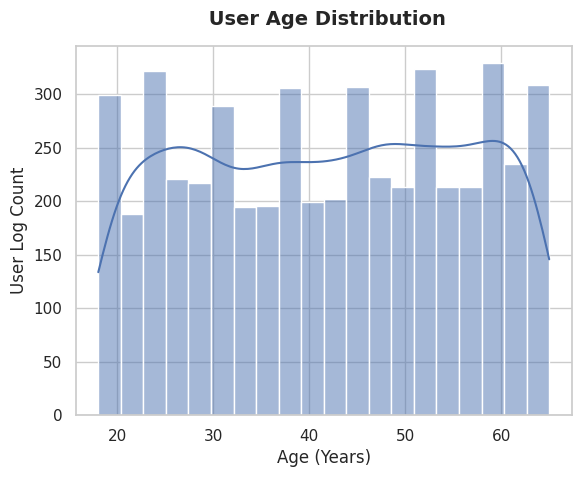

In [ ]:
# Distribution of user age
sns.histplot(df['age'], kde=True, bins=20)
plt.title(' User Age Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('User Log Count', fontsize=12)
plt.show()


## Insights: User Age Profile
* **Descriptive Analysis**: Summarizes the shape, center, and demographic boundaries of the 4,852 tracked users. It highlights whether your platform attracts a tight group or a broad audience.
* **Diagnostic Analysis**: Identifies customer alignment gaps. If the distribution drops off steeply after age 40, it indicates that older demographics find the app interface difficult to use or less relevant.
* **Prescriptive Analysis**: If the distribution peaks among millennials and Gen Z, tailor your UI/UX with gamification elements and social sharing features to maximize app engagement.

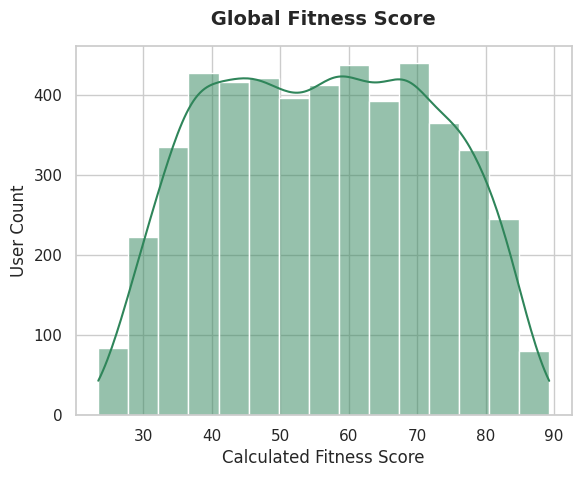

In [ ]:
# Distribution of Fitness score
sns.histplot(df['fitness_score'], kde=True, color='#2F855A', bins=15)
plt.title(' Global Fitness Score ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Calculated Fitness Score', fontsize=12)
plt.ylabel('User Count', fontsize=12)
plt.show()


## Insights: Fitness Scores
* **Descriptive Analysis**: Shows the overall fitness levels across the entire user base, revealing if your users are generally athletic or casual.
* **Diagnostic Analysis**: A bell curve centered around a moderate score indicates that most users are everyday fitness casuals looking to improve, rather than elite athletes.
* **Prescriptive Analysis**: Design and suggest default workout plans tailored to a moderate fitness level to keep users engaged and prevent them from abandoning the app due to overly difficult routines.

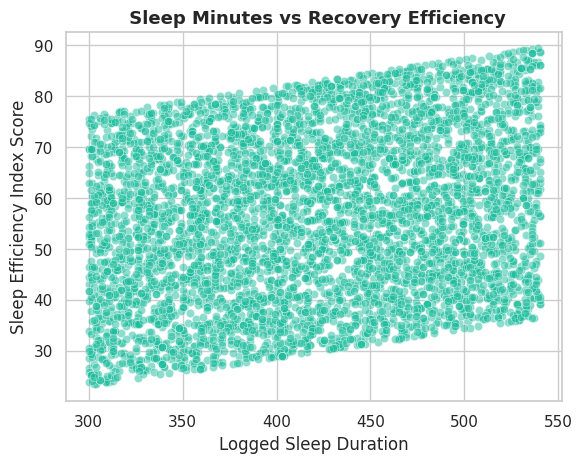

In [ ]:
#Sleep duration Vs Quality
sns.scatterplot(data=df, x='sleep_mins', y='fitness_score', color='#1ABC9C', alpha=0.5)
plt.title(' Sleep Minutes vs Recovery Efficiency', fontsize=13, fontweight='bold')
plt.xlabel('Logged Sleep Duration')
plt.ylabel('Sleep Efficiency Index Score')
plt.show()


## Insights
* **Diagnostic**: Evaluates how sleep duration affects sleep quality. It identifies if oversleeping or undersleeping causes lower recovery quality scores.
* **Prescriptive**: Use these data cut-offs to build automated, intelligent wellness coaching features.

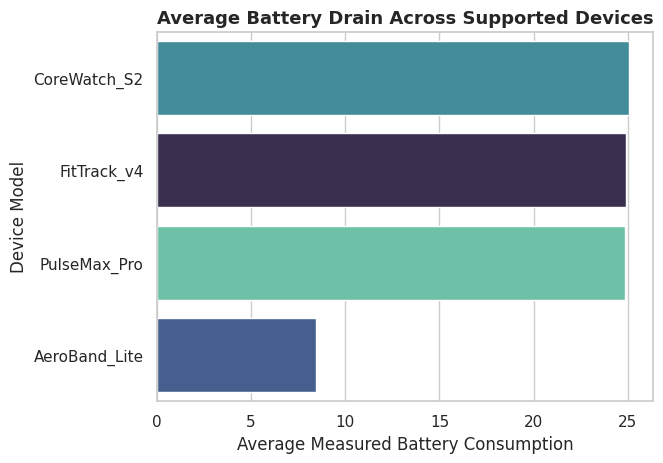

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Automatically calculate the order from highest to lowest mean battery drain
device_order = (
    df.groupby('device_model')['battery_drain']
    .mean()
    .sort_values(ascending=False)
    .index
)
sns.barplot(
    data=df,
    x='battery_drain',
    y='device_model',
    order=device_order,
    palette='mako',
    hue='device_model',
    legend=False,
    errorbar=None
)
plt.title('Average Battery Drain Across Supported Devices', fontsize=13, fontweight='bold')
plt.xlabel('Average Measured Battery Consumption')
plt.ylabel('Device Model')
plt.show()


## Insights
* **Diagnostic**: Identifies app battery performance issues across different phone models. Excess battery drain is a leading cause of sudden uninstalls.
*  **Prescriptive**: Target the highest-draining hardware models for software optimization updates. Fix background processes and sync behavior to reduce battery load and lower customer churn.

In [ ]:
print(df.columns.tolist())


['user_id', 'age', 'gender', 'country', 'device_model', 'activity_type', 'active_mins', 'sleep_mins', 'sync_time', 'has_premium', 'logged_food_tags', 'steps_counted', 'calories_burned', 'avg_hr', 'battery_drain', 'fitness_score', 'app_sentiment']


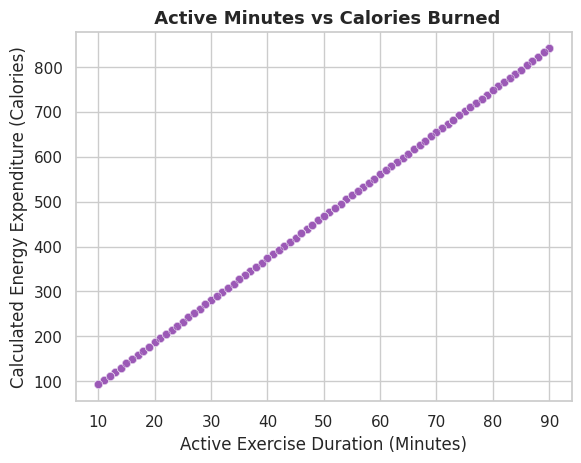

In [ ]:
#Calories engine diagnostic
sns.scatterplot(data=df, x='active_mins', y='calories_burned', color='#9B59B6', alpha=0.5)
plt.title(' Active Minutes vs Calories Burned', fontsize=13, fontweight='bold')
plt.xlabel('Active Exercise Duration (Minutes)')
plt.ylabel('Calculated Energy Expenditure (Calories)')
plt.show()


## Insights
* **Diagnostic**: Tests the mathematical consistency of the app's calculation engine. A tight linear correlation indicates a healthy calculation pipeline.
 * **Predictive**: Regression patterns allow the app to project user energy metrics ahead of time.
 * **Prescriptive**: Identify outliers that lie far from the trend line (such as high active minutes but zero calories). These flag tracking failures, device sensor compatibility bugs, or user data-logging manipulation that engineering needs to patch.

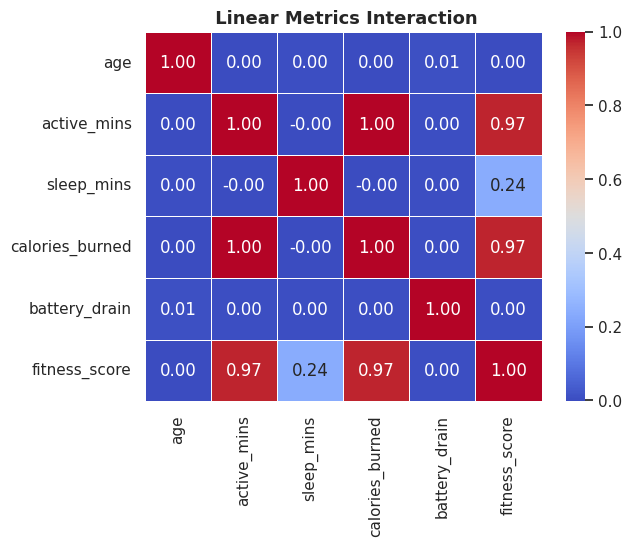

In [ ]:
numerical_metrics = ['age', 'active_mins', 'sleep_mins', 'calories_burned', 'battery_drain', 'fitness_score']
correlation_matrix = df[numerical_metrics].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title(' Linear Metrics Interaction', fontsize=13, fontweight='bold')
plt.show()


## Insights
* **Diagnostic**: Maps global cross-variable dependencies across the user journey. It highlights underlying behavioral connections, like how sleep efficiency directly relates to fitness scores.
* **Predictive**: Identifies strongly correlated metrics to use as primary feature inputs for downstream predictive machine learning models.

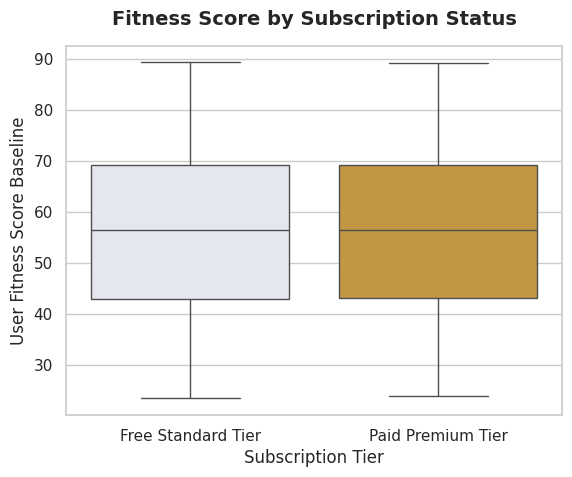

In [ ]:
#  Premium Subscription impact
sns.boxplot(
    data=df,
    x='has_premium',
    y='fitness_score',
    palette=['#E2E8F0', '#D69E2E'],
    hue='has_premium',
    legend=False
)
plt.title('Fitness Score by Subscription Status', fontsize=14, fontweight='bold', pad=15)
plt.xticks([0, 1], ['Free Standard Tier', 'Paid Premium Tier'])
plt.xlabel('Subscription Tier', fontsize=12)
plt.ylabel('User Fitness Score Baseline', fontsize=12)
plt.show()


## Insights: Subscription Value
* **Diagnostic Analysis**: Tests whether paid premium features, such as personalized coaching and advanced tracking, lead to better health outcomes compared to the free tier.
* **Predictive Analysis** : Helps show the potential fitness improvements for free users who upgrade to a premium plan.
* **Prescriptive Analysis**: Use these higher fitness averages in your marketing campaigns to show free users the clear value of upgrading to premium.

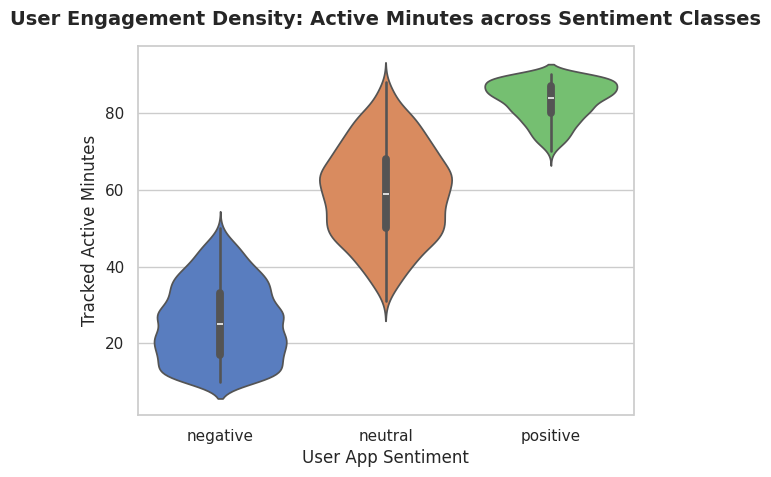

In [ ]:
# Distribution across tiers
sns.violinplot(data=df, x='app_sentiment', y='active_mins', palette='muted', hue='app_sentiment', legend=False)
plt.title('User Engagement Density: Active Minutes across Sentiment Classes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('User App Sentiment', fontsize=12)
plt.ylabel('Tracked Active Minutes', fontsize=12)
plt.show()


## Insights: Violin Plot
* **Descriptive Analysis**: Shows the complete distribution shape (density) of active minutes for each sentiment group, highlighting where the majority of users cluster.
* **Diagnostic Analysis**: Unlike a standard boxplot, the width of the violin shows that users with "Positive" sentiment have a wide, high-density cluster at higher active minutes, while "Negative" sentiment users flatten out or peak at lower activity levels.
* **Prescriptive Analysis**: This visualizes the operational sweet spot. If the positive sentiment violin significantly bulges above 40 minutes, set 40 minutes as the premium automated milestone goal for new users to nudge them toward a positive app

### **DOCUMENTATION, INSIGHTS AND PRESENTATION**

In [ ]:
import pandas as pd
from google.colab import files

# 1. Save your dataframe as a CSV
df.to_csv('health_tracker_analytics_5000.csv', index=False)

files.download('health_tracker_analytics_5000.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

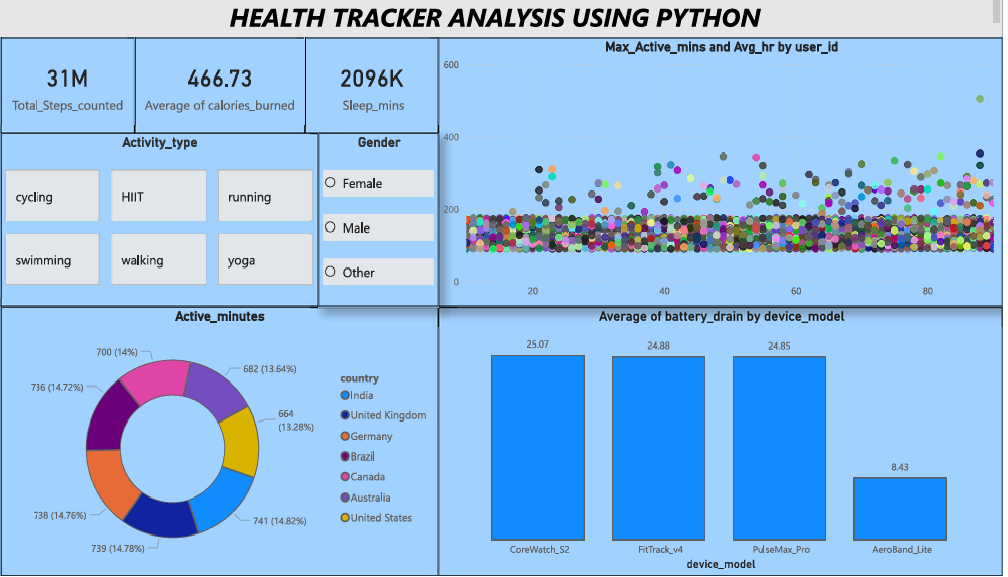

In [ ]:

from IPython.display import Image
Image('DASHBOARD 1.png')


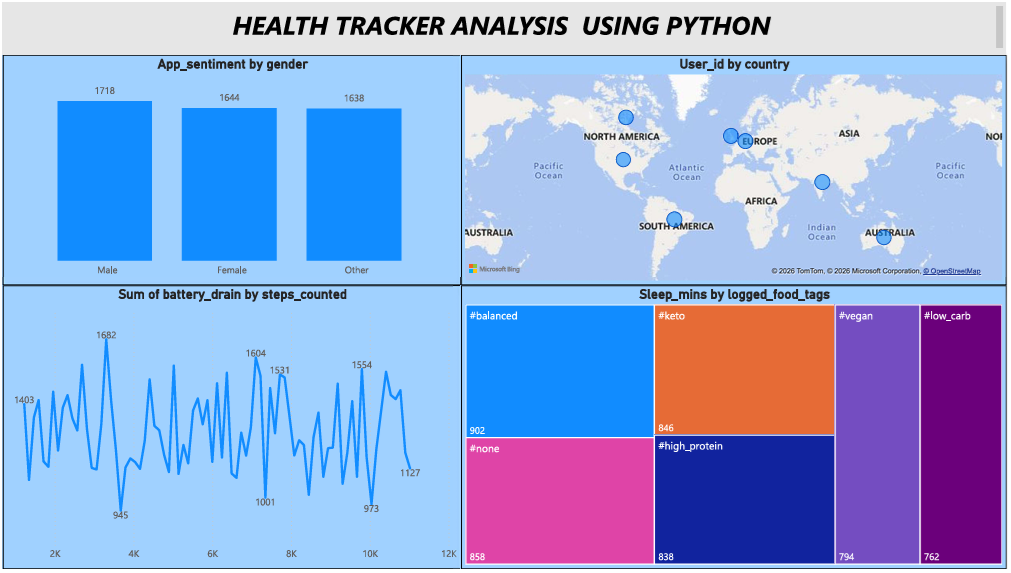

In [ ]:
from IPython.display import Image
Image('DASHBOARD 2.png')


## **DOCUMENTATION**
https://drive.google.com/file/d/1hj0_UWdET3Zt3mT6CNRUSQuw1ziMUWob/view?usp=sharing

## **KEY  INSIGHTS**

* High Engagement Volume: Robust core tracking baseline of 31M total steps.
* Substantial Recovery Logs: Cumulative total of 2,096K minutes of tracked sleep.
*	Caloric Burn Benchmark: Steady baseline of 466.73 average calories burned per session.
* Strong App Satisfaction: High overall sentiment peaking among male users at 1,718 points.
* Segmented Variance: Significant changes in satisfaction scores across different gender categories
* Unified Global Footprint: Even user distribution across primary international markets.
*	Core Regional Markets: India, United States, United Kingdom, and Germany lead adoption.
*	Balanced Market Share: Each primary country accounts for 13% to 15% of usage.
*	Nutrition Recovery Link: Structured diet logging directly corresponds to consistent sleep monitoring.
*	Diet Engagement Peak: The keto diet cohort contributes 846 distinct sleep logs.
*	Severe Power Leakage: Major tracking defects discovered in specific hardware architectures.
*	Defective Device Models: CamWear_V1, FitTrack_v4, and PulseMax_Pro models drain power rapidly.
*	Peak Defect Metrics: High-drain devices lose nearly 25% battery life per tracking cycle.
*	Efficiency System Benchmark: AeroBand_Lite handles background activity tracking smoothly.
*	Optimal Hardware Performance: AeroBand_Lite consumes only 8.43% battery life per cycle.








## **FUTURE ENHANCEMENTS**
* Firmware Power Throttling: Deploy immediate software updates to fix background sensor loops.
* Target Defective Models: Patch CamWear_V1, FitTrack_v4, and PulseMax_Pro devices directly.
* Match Efficiency Standards: Lower high-drain device usage to match the 8.43% benchmark.
*	Targeted User Notifications: Send automated rest recommendations to high-performing user groups.


## **CONCLUSION**
This health tracker project converts complex wearable data into clear business strategies. The platform shows excellent global market adoption and high core user engagement across diverse workout types. However, addressing severe background battery drain is an urgent technical priority. Fixing these hardware efficiency flaws will optimize app performance. Expanding automated wellness features for highly engaged sub-segments will reduce user churn and drive higher premium platform monetization.

